In [268]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [269]:
df = pd.read_csv(r"E:\BLAS\TRADING\BACKTESTING\Data Historical\5M\2M\BATS_INTC, 2.csv")
df.tail()

,time,open,high,low,close,VWAP,Upper Band #1,Lower Band #1,MA,MA.1,MA.2,MA.3,Volume,SPX · SPCFD: open,SPX · SPCFD: high,SPX · SPCFD: low,SPX · SPCFD: close
20290,2026-03-20T16:50:00-03:00,43.900000,44.090000,43.870000,44.040000,45.182856,46.186835,44.178876,43.873889,44.944685,43.840476,43.943600,143246,"6,485.740000","6,494.470000","6,485.020000","6,494.430000"
20291,2026-03-20T16:52:00-03:00,44.030000,44.115000,43.990000,44.115000,45.168261,46.173595,44.162928,43.912222,44.934560,43.858333,43.937300,81764,"6,494.510000","6,501.730000","6,493.190000","6,501.730000"
20292,2026-03-20T16:54:00-03:00,44.115000,44.150000,43.870000,44.020000,45.138258,46.147312,44.129203,43.950000,44.924285,43.867381,43.929400,165790,"6,501.500000","6,508.860000","6,498.640000","6,507.030000"
20293,2026-03-20T16:56:00-03:00,44.030000,44.070000,43.910000,43.935000,45.118359,46.130111,44.106608,43.968333,44.913410,43.869048,43.921300,110742,"6,507.440000","6,508.620000","6,505.150000","6,507.750000"
20294,2026-03-20T16:58:00-03:00,43.930000,43.940000,43.880000,43.940000,45.075569,46.093674,44.057465,43.968333,44.902360,43.874762,43.913300,240414,"6,507.240000","6,508.690000","6,504.470000","6,506.390000"


In [270]:
df.isnull().sum()

time                    0
open                    0
high                    0
low                     0
close                   0
VWAP                    0
Upper Band #1           0
Lower Band #1           0
MA                      8
MA.1                  199
MA.2                   20
MA.3                   49
Volume                  0
SPX · SPCFD: open       0
SPX · SPCFD: high       0
SPX · SPCFD: low        0
SPX · SPCFD: close      0
dtype: int64

In [271]:
df.duplicated().sum()

np.int64(0)

In [272]:
df.drop_duplicates(inplace=True)

In [273]:
df.duplicated().sum()

np.int64(0)

In [274]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20295 entries, 0 to 20294
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   time                20295 non-null  object 
 1   open                20295 non-null  float64
 2   high                20295 non-null  float64
 3   low                 20295 non-null  float64
 4   close               20295 non-null  float64
 5   VWAP                20295 non-null  float64
 6   Upper Band #1       20295 non-null  float64
 7   Lower Band #1       20295 non-null  float64
 8   MA                  20287 non-null  float64
 9   MA.1                20096 non-null  float64
 10  MA.2                20275 non-null  float64
 11  MA.3                20246 non-null  float64
 12  Volume              20295 non-null  int64  
 13  SPX · SPCFD: open   20295 non-null  float64
 14  SPX · SPCFD: high   20295 non-null  float64
 15  SPX · SPCFD: low    20295 non-null  float64
 16  SPX 

In [275]:
df['time'] = pd.to_datetime(df['time'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20295 entries, 0 to 20294
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype                    
---  ------              --------------  -----                    
 0   time                20295 non-null  datetime64[ns, UTC-03:00]
 1   open                20295 non-null  float64                  
 2   high                20295 non-null  float64                  
 3   low                 20295 non-null  float64                  
 4   close               20295 non-null  float64                  
 5   VWAP                20295 non-null  float64                  
 6   Upper Band #1       20295 non-null  float64                  
 7   Lower Band #1       20295 non-null  float64                  
 8   MA                  20287 non-null  float64                  
 9   MA.1                20096 non-null  float64                  
 10  MA.2                20275 non-null  float64                  
 11  MA.3           

In [276]:
df.sort_values('time', inplace=True)
df.set_index('time', inplace=True)


In [277]:
df.head()

,open,high,low,close,VWAP,Upper Band #1,Lower Band #1,MA,MA.1,MA.2,MA.3,Volume,SPX · SPCFD: open,SPX · SPCFD: high,SPX · SPCFD: low,SPX · SPCFD: close
time,,,,,,,,,,,,,,,,
2025-10-20 10:30:00-03:00,37.570000,38.380000,37.560000,38.110000,38.016667,38.016667,38.016667,NaN,NaN,NaN,NaN,288231,"6,690.050000","6,705.830000","6,690.050000","6,704.400000"
2025-10-20 10:32:00-03:00,38.120000,38.240000,37.910000,38.100000,38.035187,38.065048,38.005326,NaN,NaN,NaN,NaN,110871,"6,704.320000","6,709.720000","6,704.320000","6,707.330000"
2025-10-20 10:34:00-03:00,38.110000,38.210000,38.030000,38.160000,38.054257,38.101443,38.007072,NaN,NaN,NaN,NaN,96251,"6,707.290000","6,709.230000","6,705.630000","6,709.230000"
2025-10-20 10:36:00-03:00,38.170000,38.250000,38.000000,38.000000,38.059141,38.103533,38.014750,NaN,NaN,NaN,NaN,100002,"6,710.000000","6,713.080000","6,709.880000","6,711.130000"
2025-10-20 10:38:00-03:00,38.000000,38.140000,37.910000,37.995000,38.054743,38.098891,38.010594,NaN,NaN,NaN,NaN,65892,"6,711.120000","6,712.450000","6,709.320000","6,709.320000"


FUNCION DEL BACKTEST

In [278]:

def backtest_opening_range_breakout(df):
    # Copia de seguridad
    data = df.copy()

    # Asegurar que el índice sea datetime
    data.index = pd.to_datetime(data.index)

    # Ordenar por tiempo
    data = data.sort_index()

    # Crear columna de fecha para agrupar por sesión
    data["session_date"] = data.index.date

    trades = []

   

    for session_date, day in data.groupby("session_date"):
        day = day.copy().drop(columns="session_date")
        day = day.sort_index()

        # Necesitamos al menos 2 velas: una de apertura + una posterior
        if len(day) < 2:
            continue

        # Primera vela de la sesión
        first_bar = day.iloc[0]
        first_bar_time = day.index[0]

        opening_high = first_bar["high"]
        opening_low = first_bar["low"]
        opening_range = abs(opening_high - opening_low)
        return_op = 1.5*opening_range

        # Si el rango es 0, no tiene sentido operar
        if opening_range == 0:
            continue

        # Niveles de la estrategia
        entry_price = opening_high
        stop_price = opening_low
        target_price = opening_high + return_op

        # Velas posteriores a la apertura
        after_open = day.iloc[1:]

        result = None
        exit_time = None
        exit_price = None
        entered = False
        entry_time = None

        for current_time, row in after_open.iterrows():
            bar_high = row["high"]
            bar_low = row["low"]
            # Si todavía no entramos, buscar ruptura de entrada
            if not entered:
                    if bar_high <= entry_price:
                        continue

                    entered = True
                    entry_time = current_time
            # Una vez que ya entramos, revisar salida
            hit_target = bar_high >= target_price
            hit_stop = bar_low < stop_price
            #entry_long = bar_high > entry_price

            # No se activa la operación si el precio no supera el nivel de entrada
            #if bar_high <= entry_price:
                #continue

            # Caso ambiguo: en la misma vela toca target y stop
            # Regla conservadora: contar como pérdida
            if hit_target and hit_stop:
                result = "loss_ambiguous_same_bar"
                exit_time = current_time
                exit_price = stop_price
                pnl_points = -opening_range
                break

            elif hit_target:
                result = "win"
                exit_time = current_time
                exit_price = target_price
                pnl_points = opening_range
                break

            elif hit_stop:
                result = "loss"
                exit_time = current_time
                exit_price = stop_price
                pnl_points = -opening_range
                break

        # Si no tocó ni target ni stop en toda la sesión
        if entered and result is None:
            result = "no_exit"
            exit_time = day.index[-1]
            exit_price = day.iloc[-1]["close"]
            pnl_points = exit_price - entry_price
        elif not entered:
            continue

        trades.append({
            "session_date": session_date,
            "entry_time": entry_time,
            "entry_price": entry_price,
            "stop_price": stop_price,
            "target_price": target_price,
            "opening_range": opening_range,
            "exit_time": exit_time,
            "exit_price": exit_price,
            "result": result,
            "pnl_points": pnl_points,
            "return_pct": (pnl_points / entry_price) * 100
        })

    trades_df = pd.DataFrame(trades)

    return trades_df

EJECUTAR EL LA FUNCION BACKTEST

In [279]:
trades = backtest_opening_range_breakout(df)
trades.tail()

,session_date,entry_time,entry_price,stop_price,target_price,opening_range,exit_time,exit_price,result,pnl_points,return_pct
78,2026-03-10,2026-03-10 10:32:00-03:00,46.440000,45.400000,48.000000,1.040000,2026-03-10 16:58:00-03:00,46.790000,no_exit,0.350000,0.753661
79,2026-03-11,2026-03-11 10:32:00-03:00,47.279000,46.660000,48.207500,0.619000,2026-03-11 11:00:00-03:00,48.207500,win,0.619000,1.309249
80,2026-03-13,2026-03-13 10:36:00-03:00,46.600000,45.930000,47.605000,0.670000,2026-03-13 11:06:00-03:00,45.930000,loss,-0.670000,-1.437768
81,2026-03-18,2026-03-18 12:58:00-03:00,44.940000,44.110000,46.185000,0.830000,2026-03-18 16:58:00-03:00,45.030000,no_exit,0.090000,0.200267
82,2026-03-19,2026-03-19 10:38:00-03:00,44.060000,43.660000,44.660000,0.400000,2026-03-19 10:48:00-03:00,44.660000,win,0.400000,0.907853


In [280]:
def analyze_backtest(trades_df, initial_capital=10000):
    """
    Analiza resultados de un backtest a partir de un DataFrame de trades.

    Columnas esperadas en trades_df:
    - session_date
    - result
    - pnl_points
    - return_pct

    Opcionales:
    - exit_time
    - entry_time
    """

    required_cols = {"result", "pnl_points", "return_pct"}
    missing = required_cols - set(trades_df.columns)
    if missing:
        raise ValueError(f"Faltan columnas requeridas en trades_df: {missing}")

    if trades_df.empty:
        raise ValueError("trades_df está vacío")

    df = trades_df.copy()

    # Convertir fechas si existen
    if "session_date" in df.columns:
        df["session_date"] = pd.to_datetime(df["session_date"])

    if "exit_time" in df.columns:
        df["exit_time"] = pd.to_datetime(df["exit_time"])
        df = df.sort_values("exit_time")
    elif "session_date" in df.columns:
        df = df.sort_values("session_date")

    # Retornos en decimal
    df["return_decimal"] = df["return_pct"] / 100.0

    # Clasificaciones útiles
    df["is_win_strict"] = df["result"] == "win"
    df["is_loss_strict"] = df["result"].isin(["loss", "loss_ambiguous_same_bar"])
    df["is_no_exit"] = df["result"] == "no_exit"

    df["is_positive"] = df["pnl_points"] > 0
    df["is_negative"] = df["pnl_points"] < 0
    df["is_flat"] = df["pnl_points"] == 0

    total_trades = len(df)

    wins_strict = int(df["is_win_strict"].sum())
    losses_strict = int(df["is_loss_strict"].sum())
    no_exit_count = int(df["is_no_exit"].sum())

    positive_trades = int(df["is_positive"].sum())
    negative_trades = int(df["is_negative"].sum())
    flat_trades = int(df["is_flat"].sum())

    gross_profit_points = df.loc[df["pnl_points"] > 0, "pnl_points"].sum()
    gross_loss_points = abs(df.loc[df["pnl_points"] < 0, "pnl_points"].sum())
    net_profit_points = df["pnl_points"].sum()

    avg_pnl_points = df["pnl_points"].mean()
    median_pnl_points = df["pnl_points"].median()

    avg_return_pct = df["return_pct"].mean()
    median_return_pct = df["return_pct"].median()
    std_return_pct = df["return_pct"].std(ddof=1)

    best_trade_points = df["pnl_points"].max()
    worst_trade_points = df["pnl_points"].min()

    best_trade_pct = df["return_pct"].max()
    worst_trade_pct = df["return_pct"].min()

    strict_win_rate_pct = (wins_strict / total_trades) * 100 if total_trades > 0 else np.nan
    positive_trade_rate_pct = (positive_trades / total_trades) * 100 if total_trades > 0 else np.nan

    avg_win_points = df.loc[df["pnl_points"] > 0, "pnl_points"].mean()
    avg_loss_points = abs(df.loc[df["pnl_points"] < 0, "pnl_points"].mean()) if negative_trades > 0 else np.nan

    payoff_ratio = (avg_win_points / avg_loss_points) if negative_trades > 0 and avg_loss_points != 0 else np.nan
    profit_factor = (gross_profit_points / gross_loss_points) if gross_loss_points != 0 else np.inf

    expectancy_points = df["pnl_points"].mean()
    expectancy_return_pct = df["return_pct"].mean()

    # Equity curve por compounding usando return_pct
    df["equity"] = initial_capital * (1 + df["return_decimal"]).cumprod()
    df["equity_peak"] = df["equity"].cummax()
    df["drawdown_pct"] = ((df["equity"] / df["equity_peak"]) - 1) * 100
    max_drawdown_pct = df["drawdown_pct"].min()

    final_equity = df["equity"].iloc[-1]
    total_return_pct = ((final_equity / initial_capital) - 1) * 100

    # Sharpe aproximado por trade (no anualizado)
    if std_return_pct is not None and pd.notna(std_return_pct) and std_return_pct != 0:
        sharpe_per_trade = avg_return_pct / std_return_pct
    else:
        sharpe_per_trade = np.nan

    # SQN (System Quality Number)
    pnl_std = df["pnl_points"].std(ddof=1)
    sqn = (np.sqrt(total_trades) * df["pnl_points"].mean() / pnl_std) if pnl_std and pnl_std != 0 else np.nan

    # Rachas
    def longest_streak(series_bool):
        max_streak = 0
        current = 0
        for val in series_bool:
            if val:
                current += 1
                max_streak = max(max_streak, current)
            else:
                current = 0
        return max_streak

    max_consecutive_wins = longest_streak(df["pnl_points"] > 0)
    max_consecutive_losses = longest_streak(df["pnl_points"] < 0)

    # Resumen principal
    summary = pd.DataFrame([{
        "total_trades": total_trades,
        "wins_strict": wins_strict,
        "losses_strict": losses_strict,
        "no_exit_count": no_exit_count,
        "positive_trades": positive_trades,
        "negative_trades": negative_trades,
        "flat_trades": flat_trades,
        "strict_win_rate_%": strict_win_rate_pct,
        "positive_trade_rate_%": positive_trade_rate_pct,
        "gross_profit_points": gross_profit_points,
        "gross_loss_points": gross_loss_points,
        "net_profit_points": net_profit_points,
        "profit_factor": profit_factor,
        "payoff_ratio": payoff_ratio,
        "expectancy_points": expectancy_points,
        "expectancy_return_%": expectancy_return_pct,
        "avg_pnl_points": avg_pnl_points,
        "median_pnl_points": median_pnl_points,
        "avg_return_%": avg_return_pct,
        "median_return_%": median_return_pct,
        "std_return_%": std_return_pct,
        "best_trade_points": best_trade_points,
        "worst_trade_points": worst_trade_points,
        "best_trade_%": best_trade_pct,
        "worst_trade_%": worst_trade_pct,
        "max_consecutive_wins": max_consecutive_wins,
        "max_consecutive_losses": max_consecutive_losses,
        "initial_capital": initial_capital,
        "final_equity": final_equity,
        "total_return_%": total_return_pct,
        "max_drawdown_%": max_drawdown_pct,
        "sharpe_per_trade_aprox": sharpe_per_trade,
        "sqn": sqn
    }])

    # Breakdown por tipo de resultado
    result_breakdown = (
        df["result"]
        .value_counts(dropna=False)
        .rename_axis("result")
        .reset_index(name="count")
    )
    result_breakdown["pct"] = (result_breakdown["count"] / total_trades) * 100

    # Resumen mensual
    monthly_stats = None
    if "session_date" in df.columns:
        monthly = df.copy()
        monthly["month"] = monthly["session_date"].dt.to_period("M").astype(str)

        monthly_stats = monthly.groupby("month").agg(
            trades=("pnl_points", "count"),
            wins=("is_win_strict", "sum"),
            positive_trades=("is_positive", "sum"),
            net_pnl_points=("pnl_points", "sum"),
            avg_pnl_points=("pnl_points", "mean"),
            avg_return_pct=("return_pct", "mean"),
            median_return_pct=("return_pct", "median"),
            gross_profit_points=("pnl_points", lambda x: x[x > 0].sum()),
            gross_loss_points=("pnl_points", lambda x: abs(x[x < 0].sum())),
        ).reset_index()

        monthly_stats["strict_win_rate_%"] = np.where(
            monthly_stats["trades"] > 0,
            (monthly_stats["wins"] / monthly_stats["trades"]) * 100,
            np.nan
        )

        monthly_stats["positive_trade_rate_%"] = np.where(
            monthly_stats["trades"] > 0,
            (monthly_stats["positive_trades"] / monthly_stats["trades"]) * 100,
            np.nan
        )

        monthly_stats["profit_factor"] = np.where(
            monthly_stats["gross_loss_points"] != 0,
            monthly_stats["gross_profit_points"] / monthly_stats["gross_loss_points"],
            np.inf
        )

    # Equity curve para inspección
    equity_curve = df[[
        col for col in ["session_date", "exit_time", "result", "pnl_points", "return_pct", "equity", "equity_peak", "drawdown_pct"]
        if col in df.columns
    ]].copy()

    return {
        "summary": summary,
        "result_breakdown": result_breakdown,
        "monthly_stats": monthly_stats,
        "equity_curve": equity_curve,
        "trades_enriched": df
    }

In [281]:
Initial_Capital = 10000

report = analyze_backtest(trades, initial_capital=Initial_Capital)

print(report["summary"].T)
print("\nBreakdown de resultados:")
print(report["result_breakdown"])

print("\nResumen mensual:")
print(report["monthly_stats"])

print("\nEquity curve:")
print(report["equity_curve"].tail())

                                   0
total_trades               83.000000
wins_strict                31.000000
losses_strict              38.000000
no_exit_count              14.000000
positive_trades            37.000000
negative_trades            46.000000
flat_trades                 0.000000
strict_win_rate_%          37.349398
positive_trade_rate_%      44.578313
gross_profit_points        21.879000
gross_loss_points          21.170000
net_profit_points           0.709000
profit_factor               1.033491
payoff_ratio                1.284880
expectancy_points           0.008542
expectancy_return_%         0.026289
avg_pnl_points              0.008542
median_pnl_points          -0.160000
avg_return_%                0.026289
median_return_%            -0.420058
std_return_%                1.359819
best_trade_points           2.125000
worst_trade_points         -1.060000
best_trade_%                4.075957
worst_trade_%              -2.161060
max_consecutive_wins        3.000000
m

# Metricas 

In [282]:
def calculate_top10_backtest_metrics(trades_df, initial_capital=10000):
    """
    Calcula 10 métricas clave de backtesting a partir de trades_df.

    Requiere estas columnas en trades_df:
    - pnl_points
    - return_pct

    Recomendadas:
    - session_date   o   exit_time
    - result

    return_pct debe estar en porcentaje.
    Ejemplo: 1.5 significa 1.5%, no 0.015
    """

    required_cols = {"pnl_points", "return_pct"}
    missing = required_cols - set(trades_df.columns)
    if missing:
        raise ValueError(f"Faltan columnas requeridas: {missing}")

    if trades_df.empty:
        raise ValueError("trades_df está vacío")

    df = trades_df.copy()

    # -----------------------------
    # 1) Ordenar por fecha
    # -----------------------------
    if "exit_time" in df.columns:
        df["exit_time"] = pd.to_datetime(df["exit_time"])
        df = df.sort_values("exit_time").reset_index(drop=True)
        date_col = "exit_time"
    elif "session_date" in df.columns:
        df["session_date"] = pd.to_datetime(df["session_date"])
        df = df.sort_values("session_date").reset_index(drop=True)
        date_col = "session_date"
    else:
        date_col = None

    # Convertir retorno a decimal
    df["return_decimal"] = df["return_pct"] / 100.0

    # -----------------------------
    # 2) Métricas base
    # -----------------------------
    total_trades = len(df)

    # Win rate basado en pnl real
    wins = (df["pnl_points"] > 0).sum()
    losses = (df["pnl_points"] < 0).sum()
    flats = (df["pnl_points"] == 0).sum()

    win_rate_pct = (wins / total_trades) * 100 if total_trades > 0 else np.nan

    # Expectancy
    expectancy_points = df["pnl_points"].mean()
    expectancy_return_pct = df["return_pct"].mean()

    # Profit factor
    gross_profit = df.loc[df["pnl_points"] > 0, "pnl_points"].sum()
    gross_loss = abs(df.loc[df["pnl_points"] < 0, "pnl_points"].sum())
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf

    # Payoff ratio
    avg_win = df.loc[df["pnl_points"] > 0, "pnl_points"].mean()
    avg_loss = abs(df.loc[df["pnl_points"] < 0, "pnl_points"].mean()) if losses > 0 else np.nan
    payoff_ratio = avg_win / avg_loss if losses > 0 and avg_loss != 0 else np.nan

    # -----------------------------
    # 3) Equity curve y drawdown
    # -----------------------------
    df["equity"] = initial_capital * (1 + df["return_decimal"]).cumprod()
    df["equity_peak"] = df["equity"].cummax()
    df["drawdown_pct"] = (df["equity"] / df["equity_peak"] - 1) * 100

    final_equity = df["equity"].iloc[-1]
    total_return_pct = (final_equity / initial_capital - 1) * 100
    max_drawdown_pct = df["drawdown_pct"].min()   # valor negativo

    # Retorno sobre drawdown
    return_over_drawdown = (
        total_return_pct / abs(max_drawdown_pct)
        if pd.notna(max_drawdown_pct) and max_drawdown_pct != 0
        else np.inf
    )

    # -----------------------------
    # 4) Racha máxima de pérdidas
    # -----------------------------
    def max_consecutive_losses(pnl_series):
        max_streak = 0
        current_streak = 0

        for pnl in pnl_series:
            if pnl < 0:
                current_streak += 1
                max_streak = max(max_streak, current_streak)
            else:
                current_streak = 0

        return max_streak

    max_loss_streak = max_consecutive_losses(df["pnl_points"])

    # -----------------------------
    # 5) Consistencia mensual
    #    % de meses con pnl neto positivo
    # -----------------------------
    monthly_stats = None
    winning_months_pct = np.nan

    if date_col is not None:
        monthly = df.copy()
        monthly["month"] = monthly[date_col].dt.to_period("M").astype(str)

        monthly_stats = (
            monthly.groupby("month")
            .agg(
                trades=("pnl_points", "count"),
                net_pnl_points=("pnl_points", "sum"),
                avg_pnl_points=("pnl_points", "mean"),
                avg_return_pct=("return_pct", "mean"),
            )
            .reset_index()
        )

        monthly_stats["winning_month"] = monthly_stats["net_pnl_points"] > 0

        total_months = len(monthly_stats)
        winning_months = monthly_stats["winning_month"].sum()

        winning_months_pct = (
            (winning_months / total_months) * 100 if total_months > 0 else np.nan
        )

    # -----------------------------
    # 6) Sharpe y Sortino
    #    por trade, no anualizados
    # -----------------------------
    mean_return = df["return_decimal"].mean()
    std_return = df["return_decimal"].std(ddof=1)

    sharpe_ratio = mean_return / std_return if pd.notna(std_return) and std_return != 0 else np.nan

    downside_returns = df.loc[df["return_decimal"] < 0, "return_decimal"]
    downside_std = downside_returns.std(ddof=1)

    sortino_ratio = mean_return / downside_std if pd.notna(downside_std) and downside_std != 0 else np.nan

    # -----------------------------
    # 7) Resumen final: las 10 métricas
    # -----------------------------
    metrics = pd.DataFrame({
        "metric": [
            "1. Expectancy (points)",
            "1. Expectancy (%)",
            "2. Profit Factor",
            "3. Max Drawdown (%)",
            "4. Total Trades",
            "5. Payoff Ratio",
            "6. Win Rate (%)",
            "7. Max Consecutive Losses",
            "8. Monthly Consistency (%)",
            "9. Return / Drawdown",
            "10. Sharpe Ratio",
            "10. Sortino Ratio"
        ],
        "value": [
            expectancy_points,
            expectancy_return_pct,
            profit_factor,
            max_drawdown_pct,
            total_trades,
            payoff_ratio,
            win_rate_pct,
            max_loss_streak,
            winning_months_pct,
            return_over_drawdown,
            sharpe_ratio,
            sortino_ratio
        ]
    })

    # Resumen adicional útil
    extra_summary = pd.DataFrame([{
        "total_trades": total_trades,
        "wins": wins,
        "losses": losses,
        "flats": flats,
        "gross_profit_points": gross_profit,
        "gross_loss_points": gross_loss,
        "final_equity": final_equity,
        "total_return_pct": total_return_pct,
        "max_drawdown_pct": max_drawdown_pct
    }])

    equity_curve = df.copy()

    return {
        "metrics": metrics,
        "extra_summary": extra_summary,
        "monthly_stats": monthly_stats,
        "equity_curve": equity_curve
    }

## Calculo de las Metricas

In [283]:
report = calculate_top10_backtest_metrics(trades, initial_capital=Initial_Capital)

C:\Users\Blas\AppData\Local\Temp\ipykernel_19124\1345332993.py:115: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly["month"] = monthly[date_col].dt.to_period("M").astype(str)


In [284]:
import pandas as pd
import numpy as np


def add_quick_comparison(metrics_df):
    df = metrics_df.copy()

    def get_reference(metric):
        references = {
            "1. Expectancy (points)": "Necesario > 0 | Mejor cuanto más alto",
            "1. Expectancy (%)": "Malo <= 0 | Aceptable 0.05-0.10 | Bueno 0.10-0.20 | Muy bueno > 0.20",
            "2. Profit Factor": "Malo < 1.0 | Aceptable 1.15-1.30 | Bueno 1.30-1.75 | Muy bueno > 1.75",
            "3. Max Drawdown (%)": "Excelente < 10% | Bueno 10-15% | Aceptable 15-25% | Alto > 25%",
            "4. Total Trades": "Muy poca < 50 | Preliminar 50-100 | Aceptable 100-300 | Buena > 300",
            "5. Payoff Ratio": "Malo < 0.8 | Aceptable 1.0-1.3 | Bueno 1.3-2.0 | Muy bueno > 2.0",
            "6. Win Rate (%)": "Malo < 50% | Aceptable 53-55% | Bueno 55-60% | Muy bueno > 60%",
            "7. Max Consecutive Losses": "Muy buena <= 4 | Aceptable 5-7 | Alta 8-10 | Muy dura > 10",
            "8. Monthly Consistency (%)": "Mala < 50% | Aceptable 60-70% | Buena 70-80% | Muy buena > 80%",
            "9. Return / Drawdown": "Malo < 0.5 | Aceptable 1.0-1.5 | Bueno 1.5-2.5 | Muy bueno > 2.5",
            "10. Sharpe Ratio": "Bajo < 0.5 | Aceptable 0.5-1.0 | Bueno 1.0-1.5 | Muy bueno > 1.5",
            "10. Sortino Ratio": "Bajo < 1.0 | Aceptable 1.0-1.5 | Bueno 1.5-2.5 | Muy bueno > 2.5",
        }
        return references.get(metric, "")

    def evaluate(metric, value):
        if pd.isna(value):
            return "N/A"

        if metric == "1. Expectancy (points)":
            if value <= 0:
                return "Malo"
            elif value < 0.05:
                return "Aceptable"
            elif value < 0.15:
                return "Bueno"
            else:
                return "Muy bueno"

        elif metric == "1. Expectancy (%)":
            if value <= 0:
                return "Malo"
            elif value < 0.05:
                return "Débil"
            elif value < 0.10:
                return "Aceptable"
            elif value < 0.20:
                return "Bueno"
            else:
                return "Muy bueno"

        elif metric == "2. Profit Factor":
            if value < 1.0:
                return "Malo"
            elif value < 1.15:
                return "Débil"
            elif value < 1.30:
                return "Aceptable"
            elif value < 1.75:
                return "Bueno"
            else:
                return "Muy bueno"

        elif metric == "3. Max Drawdown (%)":
            v = abs(value)
            if v < 10:
                return "Excelente"
            elif v < 15:
                return "Bueno"
            elif v < 25:
                return "Aceptable"
            elif v < 35:
                return "Alto"
            else:
                return "Muy alto"

        elif metric == "4. Total Trades":
            if value < 50:
                return "Muy poca muestra"
            elif value < 100:
                return "Preliminar"
            elif value < 300:
                return "Aceptable"
            elif value < 1000:
                return "Buena"
            else:
                return "Muy sólida"

        elif metric == "5. Payoff Ratio":
            if value < 0.8:
                return "Malo"
            elif value < 1.0:
                return "Débil"
            elif value < 1.3:
                return "Aceptable"
            elif value < 2.0:
                return "Bueno"
            else:
                return "Muy bueno"

        elif metric == "6. Win Rate (%)":
            if value < 50:
                return "Malo"
            elif value < 53:
                return "Límite"
            elif value < 55:
                return "Aceptable"
            elif value < 60:
                return "Bueno"
            else:
                return "Muy bueno"

        elif metric == "7. Max Consecutive Losses":
            if value <= 4:
                return "Muy buena"
            elif value <= 7:
                return "Aceptable"
            elif value <= 10:
                return "Alta"
            else:
                return "Muy dura"

        elif metric == "8. Monthly Consistency (%)":
            if value < 50:
                return "Mala"
            elif value < 60:
                return "Débil"
            elif value < 70:
                return "Aceptable"
            elif value < 80:
                return "Buena"
            else:
                return "Muy buena"

        elif metric == "9. Return / Drawdown":
            if value < 0.5:
                return "Malo"
            elif value < 1.0:
                return "Débil"
            elif value < 1.5:
                return "Aceptable"
            elif value < 2.5:
                return "Bueno"
            else:
                return "Muy bueno"

        elif metric == "10. Sharpe Ratio":
            if value < 0.5:
                return "Bajo"
            elif value < 1.0:
                return "Aceptable"
            elif value < 1.5:
                return "Bueno"
            else:
                return "Muy bueno"

        elif metric == "10. Sortino Ratio":
            if value < 1.0:
                return "Bajo"
            elif value < 1.5:
                return "Aceptable"
            elif value < 2.5:
                return "Bueno"
            else:
                return "Muy bueno"

        return ""

    df["referencia_rapida"] = df["metric"].apply(get_reference)
    df["diagnostico"] = df.apply(lambda row: evaluate(row["metric"], row["value"]), axis=1)

    return df


# USO
comparison = add_quick_comparison(report["metrics"])

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

print("\n=== TOP 10 MÉTRICAS CON REFERENCIAS ===")
print(comparison.to_string(index=False))


=== TOP 10 MÉTRICAS CON REFERENCIAS ===
                    metric     value                                                     referencia_rapida diagnostico
    1. Expectancy (points)  0.008542                                 Necesario > 0 | Mejor cuanto más alto   Aceptable
         1. Expectancy (%)  0.026289  Malo <= 0 | Aceptable 0.05-0.10 | Bueno 0.10-0.20 | Muy bueno > 0.20       Débil
          2. Profit Factor  1.033491 Malo < 1.0 | Aceptable 1.15-1.30 | Bueno 1.30-1.75 | Muy bueno > 1.75       Débil
       3. Max Drawdown (%) -9.630283        Excelente < 10% | Bueno 10-15% | Aceptable 15-25% | Alto > 25%   Excelente
           4. Total Trades 83.000000   Muy poca < 50 | Preliminar 50-100 | Aceptable 100-300 | Buena > 300  Preliminar
           5. Payoff Ratio  1.284880      Malo < 0.8 | Aceptable 1.0-1.3 | Bueno 1.3-2.0 | Muy bueno > 2.0   Aceptable
           6. Win Rate (%) 44.578313        Malo < 50% | Aceptable 53-55% | Bueno 55-60% | Muy bueno > 60%        Malo
 7. Max

## Equity curve

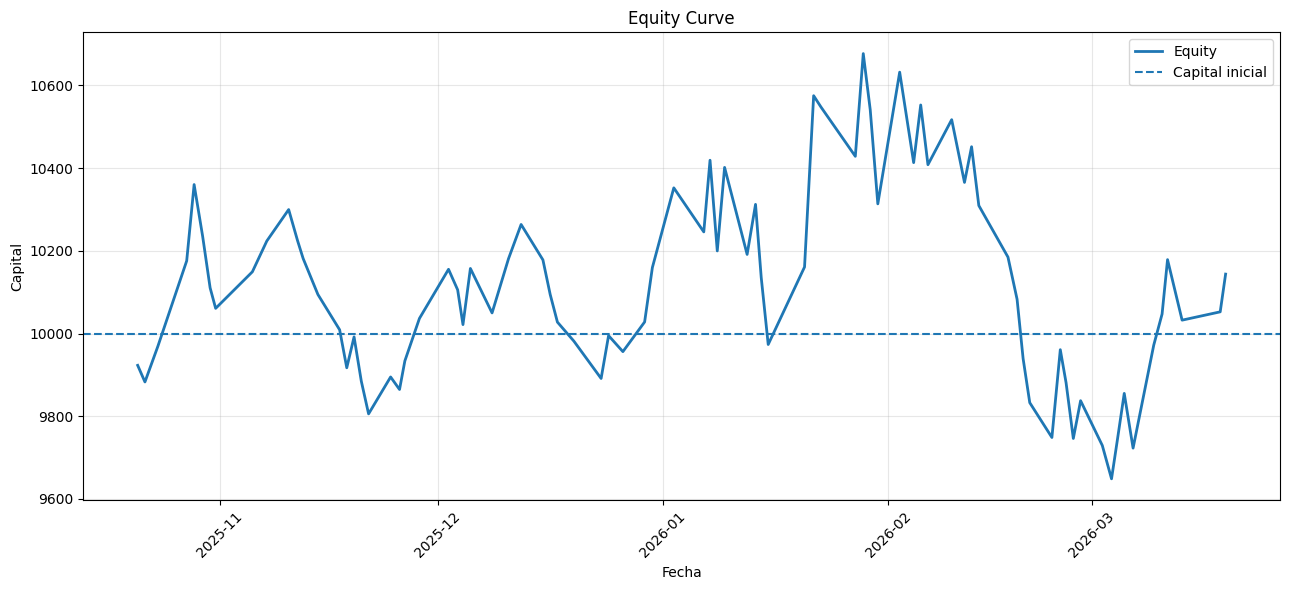

In [285]:
import matplotlib.pyplot as plt
import pandas as pd

equity_df = report["equity_curve"].copy()

if "exit_time" in equity_df.columns:
    equity_df["plot_date"] = pd.to_datetime(equity_df["exit_time"])
elif "session_date" in equity_df.columns:
    equity_df["plot_date"] = pd.to_datetime(equity_df["session_date"])
else:
    equity_df["plot_date"] = range(len(equity_df))

equity_df = equity_df.sort_values("plot_date")

initial_capital = 10000  # usa el mismo valor que pasaste a la función

plt.figure(figsize=(13, 6))
plt.plot(equity_df["plot_date"], equity_df["equity"], linewidth=2, label="Equity")
plt.axhline(initial_capital, linestyle="--", linewidth=1.5, label="Capital inicial")

plt.title("Equity Curve")
plt.xlabel("Fecha")
plt.ylabel("Capital")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Drawdown curve

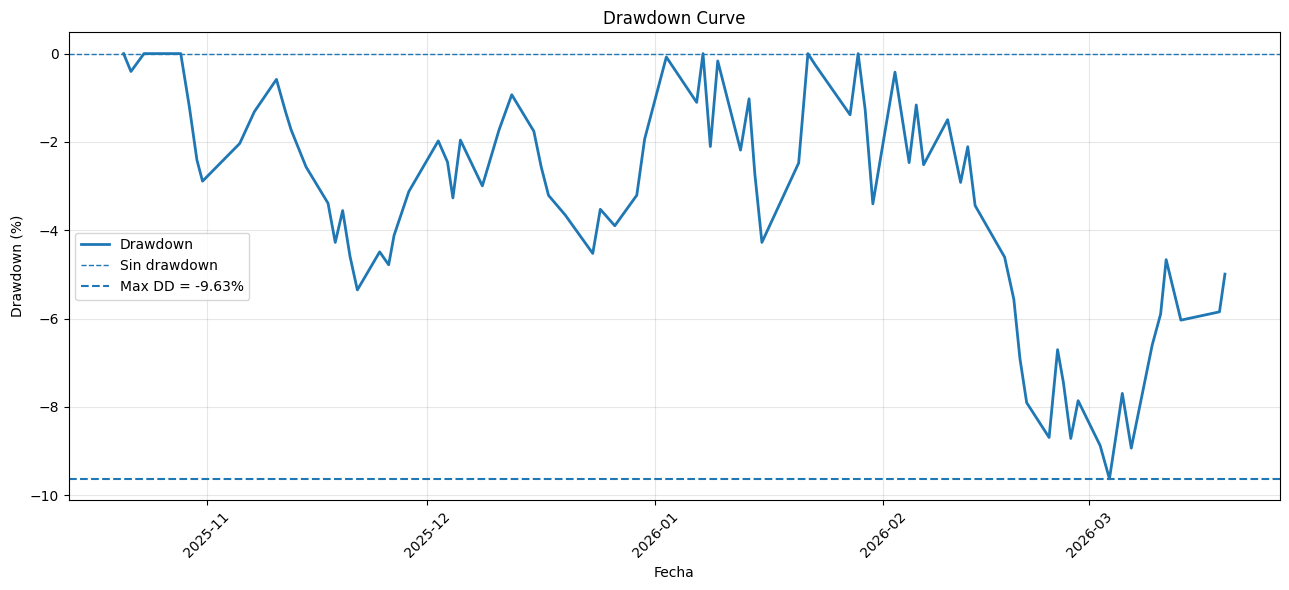

In [286]:
import matplotlib.pyplot as plt
import pandas as pd

drawdown_df = report["equity_curve"].copy()

if "exit_time" in drawdown_df.columns:
    drawdown_df["plot_date"] = pd.to_datetime(drawdown_df["exit_time"])
elif "session_date" in drawdown_df.columns:
    drawdown_df["plot_date"] = pd.to_datetime(drawdown_df["session_date"])
else:
    drawdown_df["plot_date"] = range(len(drawdown_df))

drawdown_df = drawdown_df.sort_values("plot_date")

max_dd = drawdown_df["drawdown_pct"].min()

plt.figure(figsize=(13, 6))
plt.plot(drawdown_df["plot_date"], drawdown_df["drawdown_pct"], linewidth=2, label="Drawdown")
plt.axhline(0, linestyle="--", linewidth=1, label="Sin drawdown")
plt.axhline(max_dd, linestyle="--", linewidth=1.5, label=f"Max DD = {max_dd:.2f}%")

plt.title("Drawdown Curve")
plt.xlabel("Fecha")
plt.ylabel("Drawdown (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Resultado mensual 

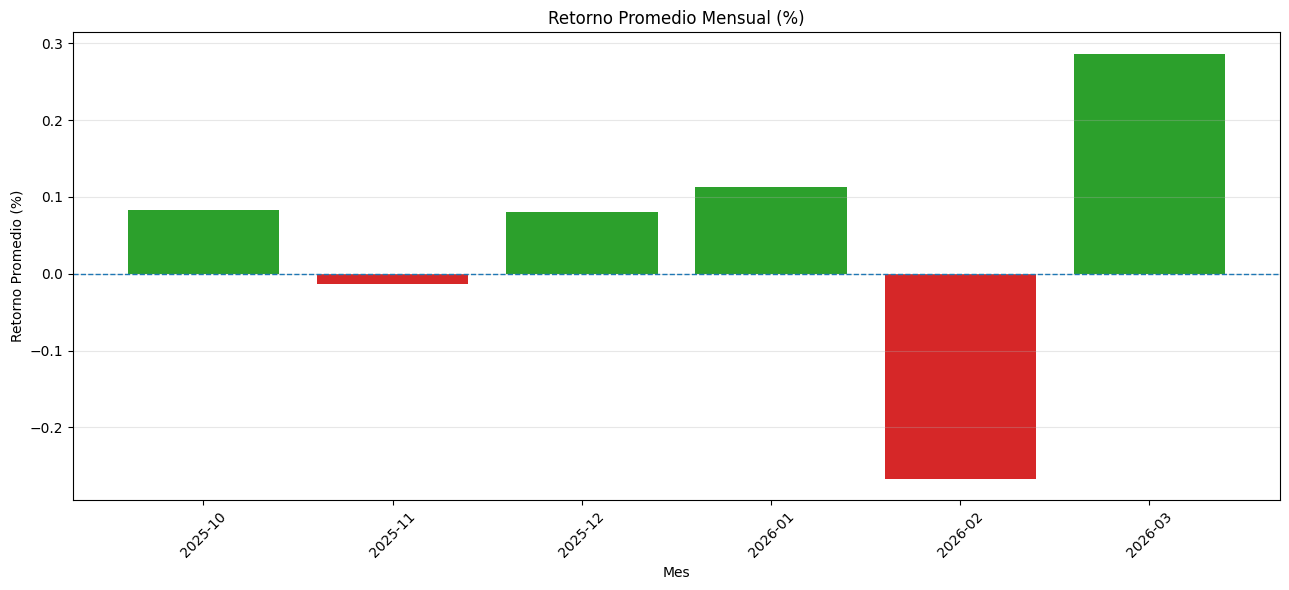

In [287]:
import matplotlib.pyplot as plt
import pandas as pd

monthly_df = report["monthly_stats"].copy()

# Convertir a fecha real para poder ordenar bien
monthly_df["month_date"] = pd.to_datetime(monthly_df["month"], format="%Y-%m")

# Ordenar cronológicamente
monthly_df = monthly_df.sort_values("month_date").reset_index(drop=True)

# Etiquetas para mostrar en el eje X
monthly_df["month_label"] = monthly_df["month_date"].dt.strftime("%Y-%m")

# Colores según si el retorno es positivo o negativo
colors = ["tab:green" if x >= 0 else "tab:red" for x in monthly_df["avg_return_pct"]]

plt.figure(figsize=(13, 6))
plt.bar(monthly_df["month_label"], monthly_df["avg_return_pct"], color=colors)
plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Retorno Promedio Mensual (%)")
plt.xlabel("Mes")
plt.ylabel("Retorno Promedio (%)")
plt.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Histograma de retornos

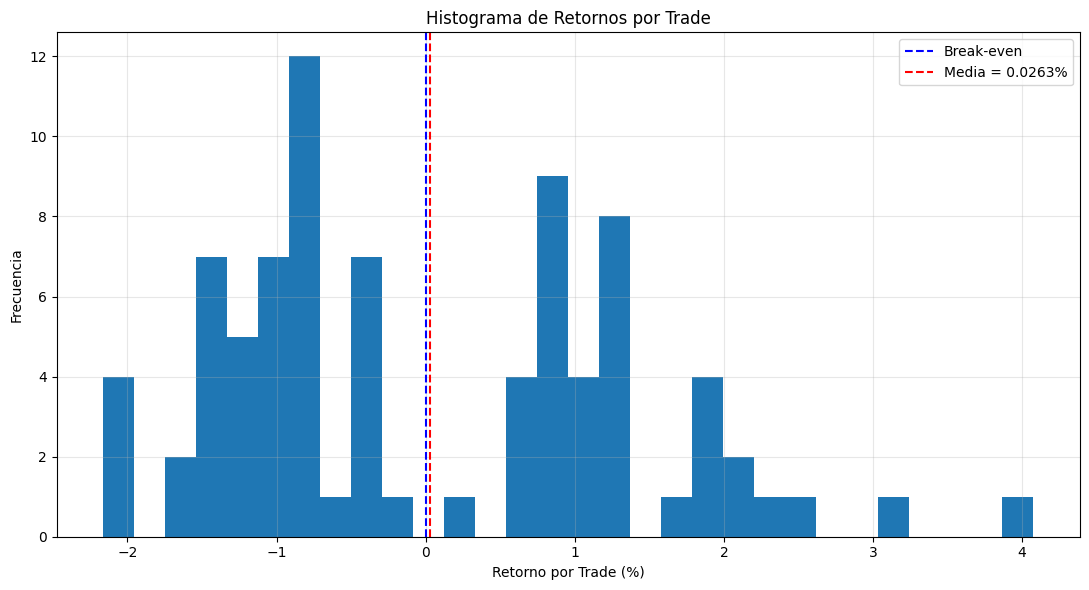

In [288]:
hist_df = report["equity_curve"].copy()
returns = hist_df["return_pct"].dropna()

mean_return = returns.mean()

plt.figure(figsize=(11, 6))
plt.hist(returns, bins=30)
plt.axvline(0, linestyle="--", linewidth=1.5, color="blue", label="Break-even")
plt.axvline(mean_return, linestyle="--", linewidth=1.5, color="red", label=f"Media = {mean_return:.4f}%")

plt.title("Histograma de Retornos por Trade")
plt.xlabel("Retorno por Trade (%)")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()